# Practical 5 — Species Classification

**Context:** MegaDetector detects *animal* — but not which species.
Species classification is the second stage of the camera trap pipeline:

```
images -> MegaDetector (detect animal) -> crops -> species classifier (this notebook)
```

We compare two classifiers on the same MegaDetector crops:

| Classifier | Architecture | Species | Geographic scope |
|-----------|-------------|---------|------------------|
| **SpeciesNet** (Google) | EfficientNetV2-M, 480x480 | 2000+ | Global (with geofencing) |
| **DeepFaune** (CNRS) | DINOv2 ViT-L/14, 182x182 | 34 taxa | Central/Western Europe |

**Learning goals:**
- Understand the two-stage pipeline: detection then classification
- Run SpeciesNet on Serengeti camera trap crops
- Run DeepFaune (a European model) on the same African data
- Discuss what happens when you apply a model outside its training domain

**Prerequisites:** Run `practical_3_megadetector_legacy.ipynb` or
`practical_3_megadetector_ultralytics.ipynb` first to generate the animal crops.

---

## Environment Setup

```bash
# SpeciesNet
pip install speciesnet

# DeepFaune (clone + weights)
cd ~/repos  # or wherever you keep cloned repos
git clone https://github.com/cwinkelmann/deepfaune.git
pip install timm dill hachoir
# Download weights into the deepfaune/ directory:
#   deepfaune-yolov8s_960.pt
#   deepfaune-vit_large_patch14_dinov2.lvd142m.v4.pt
# (see https://huggingface.co/Addax-Data-Science/Deepfaune_v1.2)
```

In [1]:
# Colab only — install dependencies if not already available
# import sys

# !git clone -b course_draft https://github.com/cwinkelmann/usde-innovations-applications-forest-it.git fit-course
# !cd fit-course && git pull
# !pip install -e "./fit-course[training,dev]"
#
# sys.path.append('./fit-course')

In [2]:
%matplotlib inline

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")
IMG_DIR = DATA_DIR / "camera_trap" / "serengeti_subset"

# MegaDetector output from Practical 3 (try v1000 first, fall back to legacy)
MD_OUTPUT_V1000 = DATA_DIR / "megadetector_output_v1000"
MD_OUTPUT_LEGACY = DATA_DIR / "megadetector_output"

if (MD_OUTPUT_V1000 / "v1000_detections.json").exists():
    MD_OUTPUT = MD_OUTPUT_V1000
    MD_JSON = MD_OUTPUT / "v1000_detections.json"
    print(f"Using MD v1000 output: {MD_JSON}")
elif (MD_OUTPUT_LEGACY / "mdv5a_detections.json").exists():
    MD_OUTPUT = MD_OUTPUT_LEGACY
    MD_JSON = MD_OUTPUT / "mdv5a_detections.json"
    print(f"Using MDv5A legacy output: {MD_JSON}")
else:
    raise FileNotFoundError(
        "No MegaDetector output found. Run Practical 3 first."
    )

CROPS_DIR = MD_OUTPUT / "animal_crops"
OUTPUT_DIR = DATA_DIR / "species_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load MegaDetector JSON
with open(MD_JSON) as f:
    md_data = json.load(f)

crop_files = sorted(CROPS_DIR.glob("*.*"))
print(f"Animal crops: {len(crop_files)} in {CROPS_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Using MD v1000 output: ../data/megadetector_output_v1000/v1000_detections.json
Animal crops: 117 in ../data/megadetector_output_v1000/animal_crops
Output dir:   ../data/species_output


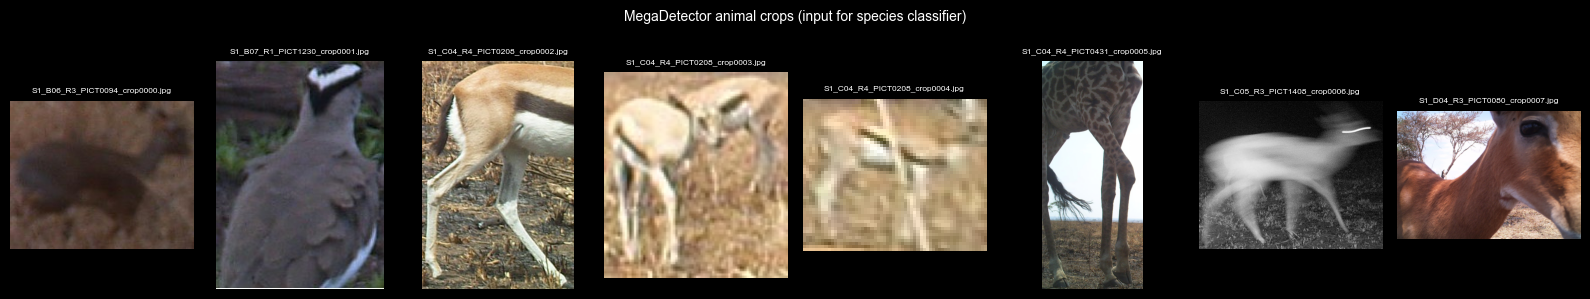

In [3]:
%matplotlib inline

# Show a few crops as reminder
n_show = min(8, len(crop_files))
fig, axes = plt.subplots(1, n_show, figsize=(16, 3))
if n_show == 1:
    axes = [axes]
for ax, cp in zip(axes, crop_files[:n_show]):
    ax.imshow(Image.open(cp))
    ax.set_title(cp.name, fontsize=6)
    ax.axis("off")
plt.suptitle("MegaDetector animal crops (input for species classifier)", fontsize=10)
plt.tight_layout()

---
## Part 1 — SpeciesNet (Global, 2000+ species)

SpeciesNet is Google's species classifier, trained on 65M+ camera trap images.
It uses EfficientNetV2-M (480x480 px input) and supports **geofencing** —
restricting predictions to species that actually occur in a given country.

Two usage modes:
- **Full pipeline** (`components="all"`): runs MegaDetector internally + classifies
- **Classifier only** (`components="classifier"`): uses pre-computed MegaDetector detections

We use **classifier-only mode** since we already have MegaDetector output from Practical 3.

### 1.1 — Load SpeciesNet

First run downloads the model weights from Kaggle (~500 MB). Subsequent runs use the cache.

In [4]:
from speciesnet import SpeciesNet

# Load classifier-only mode — we already have MegaDetector detections
snet = SpeciesNet(
    "kaggle:google/speciesnet/pyTorch/v4.0.2a/1",
    components="classifier",
)
print("SpeciesNet classifier loaded")

/Users/christian/opt/anaconda3/envs/fit-training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/christian/opt/anaconda3/envs/fit-training/lib/python3.11/site-packages/yolov5/utils/general.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


100%|██████████| 410/410 [00:00<00:00, 205kB/s]



100%|██████████| 119/119 [00:00<00:00, 103kB/s]


  0%|          | 0.00/349k [00:00<?, ?B/s]



  0%|          | 0.00/214M [00:00<?, ?B/s]




  0%|          | 0.00/250k [00:00<?, ?B/s]


100%|██████████| 250k/250k [00:00<00:00, 520kB/s]
100%|██████████| 349k/349k [00:00<00:00, 658kB/s]


  0%|          | 1.00M/214M [00:00<02:54, 1.28MB/s]

  1%|          | 2.00M/214M [00:01<01:34, 2.35MB/s]

  1%|▏         | 3.00M/214M [00:01<01:01, 3.59MB/s]


  0%|          | 0.00/5.11M [00:00<?, ?B/s]

100%|██████████| 5.11M/5.11M [00:00<00:00, 330MB/s]


  5%|▍         | 10.0M/214M [00:01<00:16, 13.0MB/s]

  7%|▋         | 15.0M/214M [00:01<00:12, 17.2MB/s]

  8%|▊         | 18.0M/214M [00:01<00:10, 18.7MB/s]

 10%|█         | 22.0M/214M [00:01<00:08, 23.4MB/s]

 12%|█▏        | 26.0M/214M [00:02<00:07, 27.0MB/s]

 14%|█▍        | 31.0M/214M [00:02<00:06, 29.5MB/s]

 16%|█▋        | 35.0M/214M [00:02<00:06, 29.7MB/s]

 18%|█▊        | 39.0M/214M [00:02<00:05, 32.4MB/s]

 20%|██        | 43.0M/214M [00:02<00:05, 34.5MB/s]

 22%|██▏       | 47.0M/214M [00:02<00:05, 34.0MB/s]

 24%|██▍       | 51.0M/214M [00:02<00:04, 34.9MB/s]

 26%|██▌       | 55.0M/214M [00:02<00:04, 36.0MB/s]

 28%|██▊       | 60.0M/214M [00:03<00:04, 36.5MB/s]

 30%|██▉       | 64.0M/214M [00:03<00:04, 35.3MB/s]

 32%|███▏      | 68.0M/214M [00:03<00:04, 36.6MB/s]

 34%|███▎      | 72.0M/214M [00:03<00:03, 37.5MB/s]

 36%|███▌      | 76.0M/214M [00:03<00:03, 38.4MB/s]


SpeciesNet classifier loaded


### 1.2 — Classify with pre-computed detections

We pass the original images + the MegaDetector JSON detections.
SpeciesNet will crop each image using the bounding boxes and classify.

We set `country="TZA"` (Tanzania) for geofencing — this filters out
species that don't occur in the Serengeti.

In [5]:
# Build the detections dict in SpeciesNet format
# SpeciesNet expects: {filepath: {"detections": [{"category": "1", "conf": 0.9, "bbox": [x,y,w,h]}]}}
detections_dict = {}
image_filepaths = []

for img_data in md_data["images"]:
    filepath = str(IMG_DIR / img_data["file"])
    if not Path(filepath).exists():
        continue
    # Only include images with animal detections
    animal_dets = [d for d in img_data["detections"] if d.get("category") == "1"]
    if animal_dets:
        detections_dict[filepath] = {"detections": animal_dets}
        image_filepaths.append(filepath)

print(f"Images with animal detections: {len(image_filepaths)}")

# Run classifier on original images using MD bounding boxes
snet_results = snet.classify(
    filepaths=image_filepaths,
    detections_dict=detections_dict,
    country="TZA", # Code in this format: https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3
    batch_size=8,
    progress_bars=True,
)

n_preds = len(snet_results.get("predictions", []))
print(f"\nClassified {n_preds} images")

Images with animal detections: 0


ValueError: Expected exactly one of [instances_dict, instances_json, filepaths, filepaths_txt, folders, folders_txt] to be provided. Received: [None, None, [], None, None, None].

### 1.3 — Parse SpeciesNet results

SpeciesNet returns a taxonomy string like `mammalia;carnivora;felidae;panthera;panthera_leo;lion`.
We extract the common name (last element) for display.

In [ ]:
%matplotlib inline

snet_records = []
# predictions is a list of dicts, each with "filepath" and "classifications"
predictions = snet_results.get("predictions", [])

for pred in predictions:
    filepath = pred.get("filepath", "")
    filename = Path(filepath).name
    classifications = pred.get("classifications", {})
    classes = classifications.get("classes", [])
    scores = classifications.get("scores", [])

    if classes and scores:
        top_class = classes[0]
        top_score = scores[0]
        # Extract common name from taxonomy string
        # e.g. "mammalia;carnivora;felidae;panthera;panthera_leo;lion"
        parts = top_class.split(";")
        common_name = parts[-1].replace("_", " ") if parts else top_class
        species = parts[4].replace("_", " ") if len(parts) > 4 else common_name
    else:
        common_name = "unknown"
        species = "unknown"
        top_score = 0.0
        top_class = ""

    snet_records.append({
        "filename": filename,
        "speciesnet_species": species,
        "speciesnet_common": common_name,
        "speciesnet_conf": round(top_score, 4),
        "speciesnet_full_label": top_class,
    })

snet_df = pd.DataFrame(snet_records)
print(f"\nSpeciesNet predictions: {len(snet_df)}")
print(f"\nSpecies distribution:")
print(snet_df["speciesnet_common"].value_counts().to_string())

### 1.4 — Visualize SpeciesNet predictions

In [ ]:
# Show predictions on a grid of original images
n_show = min(9, len(snet_records))
cols = 3
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flat if n_show > 1 else [axes]

for i, ax in enumerate(axes):
    if i >= n_show:
        ax.axis("off")
        continue

    rec = snet_records[i]
    img_path = IMG_DIR / rec["filename"]
    if img_path.exists():
        ax.imshow(np.array(Image.open(img_path)))
    ax.set_title(
        f"{rec['speciesnet_common']} ({rec['speciesnet_conf']:.2f})\n{rec['filename']}",
        fontsize=8,
    )
    ax.axis("off")

plt.suptitle("SpeciesNet predictions (Serengeti, geofenced to Tanzania)", fontsize=12)
plt.tight_layout()


## TODO does DeepFaune make sense here?

---
## Part 2 — DeepFaune (European, 34 taxa)

DeepFaune is a French initiative (CNRS) for automated camera trap classification.
It uses DINOv2 ViT-L/14 and covers **34 European taxa** including:
badger, bear, chamois, fox, lynx, red deer, roe deer, wild boar, wolf, etc.

**Important:** DeepFaune was trained on European wildlife. Running it on
African Serengeti images is intentionally "wrong" — this is a teaching moment
about domain mismatch.

### What will happen?
The model will try to map African species to the closest European taxon:
- Wildebeest / zebra → possibly "equid" or "cow"
- Lion → possibly "cat" or "lynx"
- Giraffe → possibly "red deer" or something unexpected

This is **not a failure** — it's a valuable lesson in transfer learning and domain shift.

### 2.1 — Load DeepFaune

Set `DEEPFAUNE_DIR` to the path where you cloned the DeepFaune repository.

In [ ]:
import sys

# ── Set this to your local DeepFaune clone ──────────────────────────────
DEEPFAUNE_DIR = Path.home() / "repos" / "deepfaune"
# ───────────────────────────────────────────────────────────────────────

if not DEEPFAUNE_DIR.exists():
    print(f"DeepFaune not found at {DEEPFAUNE_DIR}")
    print("Clone it: git clone https://github.com/cwinkelmann/deepfaune.git")
    print("Then update DEEPFAUNE_DIR above.")
    DEEPFAUNE_AVAILABLE = False
else:
    sys.path.insert(0, str(DEEPFAUNE_DIR))
    DEEPFAUNE_AVAILABLE = True
    print(f"DeepFaune directory: {DEEPFAUNE_DIR}")

### 2.2 — Run DeepFaune with MegaDetector JSON

DeepFaune's `PredictorJSON` accepts a MegaDetector JSON file directly.
It reads the bounding boxes, crops each detection, and classifies with DINOv2.

In [ ]:
if DEEPFAUNE_AVAILABLE:
    import os
    # DeepFaune expects to find weights in its own directory
    old_cwd = os.getcwd()
    os.chdir(str(DEEPFAUNE_DIR))

    from predictTools import PredictorJSON

    df_predictor = PredictorJSON(
        str(MD_JSON),
        threshold=0.3,
        maxlag=20,
        LANG="en",
    )
    df_predictor.allBatch()
    pred_classes, pred_scores, best_boxes, count = df_predictor.getPredictions()
    df_filenames = df_predictor.getFilenames()

    os.chdir(old_cwd)

    print(f"DeepFaune classified {len(df_filenames)} images")
else:
    print("Skipping DeepFaune — not installed")
    pred_classes = pred_scores = df_filenames = []

### 2.3 — Parse DeepFaune results

In [ ]:
if DEEPFAUNE_AVAILABLE and df_filenames:
    df_records = []
    for fname, cls, score in zip(df_filenames, pred_classes, pred_scores):
        df_records.append({
            "filename": Path(fname).name,
            "deepfaune_class": cls,
            "deepfaune_conf": round(float(score), 4),
        })

    df_df = pd.DataFrame(df_records)
    print(f"DeepFaune predictions: {len(df_df)}")
    print(f"\nClass distribution (European model on African data):")
    print(df_df["deepfaune_class"].value_counts().to_string())
else:
    df_df = pd.DataFrame(columns=["filename", "deepfaune_class", "deepfaune_conf"])
    print("No DeepFaune results to parse.")

### 2.4 — Visualize DeepFaune predictions

In [ ]:
if DEEPFAUNE_AVAILABLE and len(df_df) > 0:
    n_show = min(9, len(df_df))
    cols = 3
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flat if n_show > 1 else [axes]

    for i, ax in enumerate(axes):
        if i >= n_show:
            ax.axis("off")
            continue
        rec = df_df.iloc[i]
        img_path = IMG_DIR / rec["filename"]
        if img_path.exists():
            ax.imshow(np.array(Image.open(img_path)))
        ax.set_title(
            f"DeepFaune: {rec['deepfaune_class']} ({rec['deepfaune_conf']:.2f})\n{rec['filename']}",
            fontsize=8, color="red" if rec["deepfaune_conf"] < 0.5 else "black",
        )
        ax.axis("off")

    plt.suptitle("DeepFaune predictions (European model on Serengeti data)", fontsize=12)
    plt.tight_layout()
else:
    print("No DeepFaune results to visualize.")

---
## Part 3 — Side-by-side comparison

Merge SpeciesNet and DeepFaune predictions for the same images.
This reveals how a global model vs a regional model behaves on the same data.

In [ ]:
# Merge on filename
if len(df_df) > 0 and len(snet_df) > 0:
    merged = pd.merge(snet_df, df_df, on="filename", how="outer")
else:
    merged = snet_df.copy()
    if len(df_df) > 0:
        merged = pd.merge(merged, df_df, on="filename", how="outer")

# Save combined results
merged.to_csv(OUTPUT_DIR / "species_predictions.csv", index=False)

print(f"Combined results: {len(merged)} images")
print(f"Saved -> {OUTPUT_DIR / 'species_predictions.csv'}")
print()

# Show comparison table
display_cols = ["filename", "speciesnet_common", "speciesnet_conf"]
if "deepfaune_class" in merged.columns:
    display_cols += ["deepfaune_class", "deepfaune_conf"]
merged[display_cols].head(15)

In [ ]:
# Confidence comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SpeciesNet confidence
axes[0].hist(merged["speciesnet_conf"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("SpeciesNet confidence (Serengeti)")

# DeepFaune confidence
if "deepfaune_conf" in merged.columns:
    axes[1].hist(merged["deepfaune_conf"].dropna(), bins=20, color="darkorange", edgecolor="white")
    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Count")
    axes[1].set_title("DeepFaune confidence (European model on Serengeti)")
else:
    axes[1].text(0.5, 0.5, "DeepFaune not available",
                 ha="center", va="center", fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title("DeepFaune")

plt.suptitle("Confidence distributions — global vs regional model", fontsize=12)
plt.tight_layout()

In [ ]:
# Side-by-side image grid: SpeciesNet vs DeepFaune labels
if "deepfaune_class" in merged.columns:
    n_show = min(6, len(merged))
    fig, axes = plt.subplots(n_show, 2, figsize=(12, 4 * n_show))

    for i in range(n_show):
        row = merged.iloc[i]
        img_path = IMG_DIR / row["filename"]
        if img_path.exists():
            img = np.array(Image.open(img_path))
        else:
            img = np.zeros((100, 100, 3), dtype=np.uint8)

        # Left: SpeciesNet
        axes[i, 0].imshow(img)
        sn_label = row.get("speciesnet_common", "?")
        sn_conf = row.get("speciesnet_conf", 0)
        axes[i, 0].set_title(f"SpeciesNet: {sn_label} ({sn_conf:.2f})", fontsize=9)
        axes[i, 0].axis("off")

        # Right: DeepFaune
        axes[i, 1].imshow(img)
        df_label = row.get("deepfaune_class", "?")
        df_conf = row.get("deepfaune_conf", 0)
        axes[i, 1].set_title(
            f"DeepFaune: {df_label} ({df_conf:.2f})",
            fontsize=9, color="red" if isinstance(df_conf, float) and df_conf < 0.5 else "black",
        )
        axes[i, 1].axis("off")

    plt.suptitle("SpeciesNet (global) vs DeepFaune (European) on Serengeti images", fontsize=12)
    plt.tight_layout()
else:
    print("DeepFaune results not available for comparison.")

---

## Part 4 — Evaluating Classifier Results

A model that reports "92% accuracy" sounds good — but on a dataset
where 92% of images are one class, a model that always predicts that
class also gets 92%. Accuracy alone is not enough.

| Metric | Formula | When it matters |
|--------|---------|----------------|
| **Precision** | TP / (TP + FP) | Cost of false alarms is high |
| **Recall** | TP / (TP + FN) | Cost of missing cases is high |
| **F1** | 2 x P x R / (P + R) | Balance of both |

We compare SpeciesNet predictions against the ground truth species labels
from the Serengeti metadata (downloaded in Practical 1).

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load ground truth from Serengeti metadata
META_PATH = DATA_DIR / "camera_trap" / "serengeti_meta.json"

if META_PATH.exists() and len(snet_df) > 0:
    with open(META_PATH) as f:
        meta = json.load(f)
    
    cat_map = {c["id"]: c["name"] for c in meta["categories"]}
    img_id_to_file = {img["id"]: Path(img["file_name"]).name for img in meta["images"]}
    img_id_to_species = {}
    for a in meta["annotations"]:
        species = cat_map.get(a["category_id"], "unknown")
        if species != "empty":
            img_id_to_species[a["image_id"]] = species
    
    file_to_gt = {img_id_to_file[iid]: sp for iid, sp in img_id_to_species.items()
                  if iid in img_id_to_file}
    
    eval_rows = []
    for _, row in snet_df.iterrows():
        gt = file_to_gt.get(row["filename"])
        if gt and row["speciesnet_common"] != "blank":
            eval_rows.append({
                "true_label": gt,
                "pred_label": row["speciesnet_common"],
                "confidence": row["speciesnet_conf"],
            })
    
    eval_df = pd.DataFrame(eval_rows)
    print(f"Evaluation set: {len(eval_df)} images with GT + predictions")
else:
    rng = np.random.default_rng(42)
    classes = ["lion", "elephant", "zebra", "gazelle"]
    n = 100
    true_labels = rng.choice(classes, n, p=[0.15, 0.15, 0.25, 0.45])
    pred_labels = true_labels.copy()
    pred_labels[rng.choice(n, size=15, replace=False)] = rng.choice(classes, size=15)
    eval_df = pd.DataFrame({"true_label": true_labels, "pred_label": pred_labels})
    print("Using synthetic demo data")

y_true = eval_df["true_label"].tolist()
y_pred = eval_df["pred_label"].tolist()

### 4.1 — Classification report

`sklearn.metrics.classification_report` gives per-class precision, recall, and F1.

In [ ]:
print(classification_report(y_true, y_pred, digits=3, zero_division=0))

### 4.2 — Confusion matrix

Rows = true class, columns = predicted class. Off-diagonal entries are errors.
Large off-diagonal values tell you which pairs of classes the model confuses most.

In [ ]:
labels = sorted(set(y_true + y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.8), max(5, len(labels) * 0.7)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion matrix — SpeciesNet on Serengeti crops")
plt.tight_layout()

### 4.3 — Class imbalance awareness

If the dataset is imbalanced, a model that always predicts the majority class
will look good on accuracy but terrible on per-class recall.

In [ ]:
class_counts = eval_df["true_label"].value_counts()
majority_class = class_counts.idxmax()
majority_accuracy = class_counts.max() / len(eval_df)

print("Class distribution in evaluation set:")
print(class_counts.to_string())
print(f"\nA model that always predicts '{majority_class}' achieves:")
print(f"  Accuracy = {majority_accuracy:.1%}")
print(f"  Recall for all other classes = 0%")
print(f"\nThis is why F1 and per-class recall matter more than overall accuracy.")

---
## Exercises

1. **Geofencing** — Re-run SpeciesNet without geofencing (`country=None`).
   Do the predictions change? What impossible species appear?

2. **Confidence threshold** — What percentage of SpeciesNet predictions have
   confidence > 0.8? What about DeepFaune? What does the difference tell you
   about domain match?

3. **DeepFaune mappings** — For each Serengeti species that SpeciesNet correctly
   identifies, note what DeepFaune predicts. Do the mappings make biological sense?
   (e.g., does DeepFaune call a zebra an "equid"?)

4. **Wrong model, right answer?** — Are there any cases where DeepFaune gives
   a reasonable answer despite being trained on European species only?

5. **Central Europe scenario** — Imagine you deploy camera traps in the
   Black Forest (Germany). Which classifier would you choose? Why?
   What species does DeepFaune cover that SpeciesNet might miss?

## Reflection

- **Domain shift**: DeepFaune on Serengeti data is a clear example of applying a
  model outside its training domain. What happens to confidence scores?
  What happens to the predicted labels? Why doesn't the model just say "I don't know"?

- **Global vs regional models**: SpeciesNet covers 2000+ species globally.
  DeepFaune covers 34 European taxa deeply. When is a specialist model better
  than a generalist? What are the trade-offs?

- **Geofencing as guardrail**: SpeciesNet uses country-level geofencing to
  prevent impossible predictions. Is this always a good idea? What if an
  invasive species appears? What if the GPS metadata is wrong?

- **The two-stage pipeline**: MegaDetector (detect) then SpeciesNet (classify)
  is the standard camera trap workflow. What are the advantages of splitting
  detection and classification? Could you train a single end-to-end model instead?
  What would you gain and lose?